In [22]:
import geopandas as gpd 
import geodatasets

In [23]:
gpd.__version__

'1.1.3'

In [24]:
gpd.datasets.available

[]

In [25]:
from geodatasets import get_path
nybb = gpd.read_file(get_path('nybb'))

In [26]:
print(type(nybb))

<class 'geopandas.geodataframe.GeoDataFrame'>


In [27]:
nybb

,BoroCode,BoroName,Shape_Leng,Shape_Area,geometry
0,5,Staten Island,330470.010332,1.623820e+09,"MULTIPOLYGON (((970217.022 145643.332, 970227...."
1,4,Queens,896344.047763,3.045213e+09,"MULTIPOLYGON (((1029606.077 156073.814, 102957..."
2,3,Brooklyn,741080.523166,1.937479e+09,"MULTIPOLYGON (((1021176.479 151374.797, 102100..."
3,1,Manhattan,359299.096471,6.364715e+08,"MULTIPOLYGON (((981219.056 188655.316, 980940...."
4,2,Bronx,464392.991824,1.186925e+09,"MULTIPOLYGON (((1012821.806 229228.265, 101278..."


In [28]:
nybb.head()

,BoroCode,BoroName,Shape_Leng,Shape_Area,geometry
0,5,Staten Island,330470.010332,1.623820e+09,"MULTIPOLYGON (((970217.022 145643.332, 970227...."
1,4,Queens,896344.047763,3.045213e+09,"MULTIPOLYGON (((1029606.077 156073.814, 102957..."
2,3,Brooklyn,741080.523166,1.937479e+09,"MULTIPOLYGON (((1021176.479 151374.797, 102100..."
3,1,Manhattan,359299.096471,6.364715e+08,"MULTIPOLYGON (((981219.056 188655.316, 980940...."
4,2,Bronx,464392.991824,1.186925e+09,"MULTIPOLYGON (((1012821.806 229228.265, 101278..."


In [29]:
nybb.describe()

,BoroCode,Shape_Leng,Shape_Area
count,5.000000,5.000000,5.000000e+00
mean,3.000000,558317.333911,1.685981e+09
std,1.581139,249002.452978,9.034868e+08
min,1.000000,330470.010332,6.364715e+08
25%,2.000000,359299.096471,1.186925e+09
50%,3.000000,464392.991824,1.623820e+09
75%,4.000000,741080.523166,1.937479e+09
max,5.000000,896344.047763,3.045213e+09


In [30]:
nybb.keys()

Index(['BoroCode', 'BoroName', 'Shape_Leng', 'Shape_Area', 'geometry'], dtype='object')

Basic Geometry

In [31]:
import shapely 
shapely.__version__

'2.1.2'

In [21]:
from shapely.geometry import Point, LineString, Polygon, MultiPolygon

Creating a Point

In [32]:
point = Point(0,0)
type(point)

shapely.geometry.point.Point

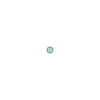

In [33]:
point

In [34]:
print(point)

POINT (0 0)


Create a LineString

In [35]:
point_1 = Point(0,0)
point_2 = Point(1.5,1.5)

points = [point_1,point_2]

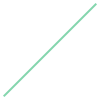

In [36]:
line = LineString(points)
line

In [37]:
print(line)

LINESTRING (0 0, 1.5 1.5)


Create a Polygon

In [38]:
point_1 = Point(0,0)
point_2 = Point(0,1)
point_3 = Point(1,1)
point_4 = Point(1,0)

points = [point_1, point_2, point_3,point_4]


In [39]:
polygon = Polygon(points)

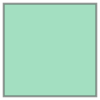

In [40]:
polygon

In [41]:
type(polygon)

shapely.geometry.polygon.Polygon

In [42]:
polygon.length

4.0

In [43]:
polygon.area

1.0

Creat Multi Geometries

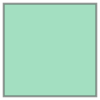

In [44]:
square = Polygon([(0,0),(0,1),(1,1),(1,0)])
square

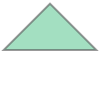

In [46]:
triangle = Polygon([(0,0),(1,1),(2,0)])
triangle

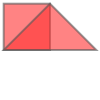

In [47]:
multipolygon = MultiPolygon([square, triangle])
multipolygon

In [48]:
print(type(multipolygon))

<class 'shapely.geometry.multipolygon.MultiPolygon'>


In [49]:
multipolygon.length

8.82842712474619

In [50]:
multipolygon.area

2.0

In [51]:
print(multipolygon)

MULTIPOLYGON (((0 0, 0 1, 1 1, 1 0, 0 0)), ((0 0, 1 1, 2 0, 0 0)))


Geometric Operations

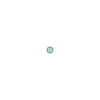

In [52]:
#Buffering geometries
point = Point(0,0)
point

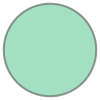

In [53]:
point_buffer = point.buffer(0.2)
point_buffer

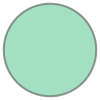

In [57]:
point_buffer = point.buffer(1.0)

point_buffer


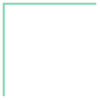

In [58]:
line = LineString([(0,0),(0,1),(1,1)])
line

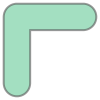

In [60]:
line_buffer = line.buffer(0.2)
line_buffer

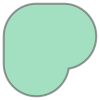

In [61]:
line_buffer = line.buffer(1.2)
line_buffer

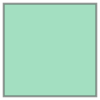

In [62]:
square = Polygon([(0,0),(0,1),(1,1),(1,0)])
square

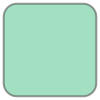

In [63]:
square.buffer(0.2)

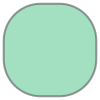

In [64]:
square.buffer(2.0)

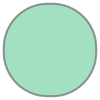

In [65]:
square.buffer(10.0)

Centroid


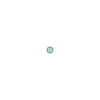

In [66]:
center_line = line.centroid
center_line

In [67]:
print(type(center_line))

<class 'shapely.geometry.point.Point'>


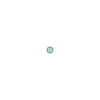

In [68]:
center_square = square.centroid
center_square

Convex Hull

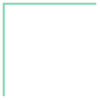

In [70]:
line 

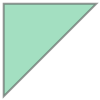

In [71]:
line.convex_hull

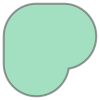

In [72]:
line_buffer

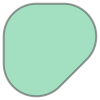

In [73]:
line_buffer.convex_hull

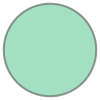

In [74]:
circle_1 = Point(0,0).buffer(2)
circle_2 = Point(3,0).buffer(2)
circle_1

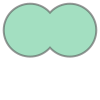

In [75]:
circle_1.union(circle_2)

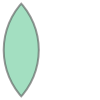

In [76]:
circle_1.intersection(circle_2)

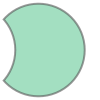

In [77]:
circle_2.difference(circle_1)

In [ ]:
#within command
point = Point(0,0)
triangle_1 = Polygon([(-1,-1),(0,1),(1,-1)])
triangle_2 = Polygon([(1,1),(2,0),(3,1)])
point.within(triangle_1)


False

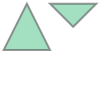

In [81]:
point.union(triangle_1).union(triangle_2)